<BarContainer object of 20 artists>

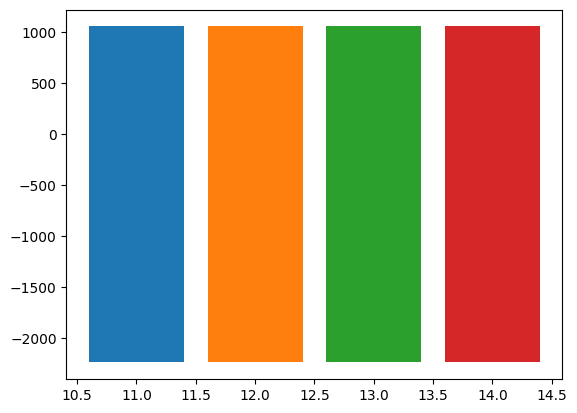

In [20]:
import matplotlib.pyplot as plt
import numpy as np

def fct(x):
    return - x ** 2 * np.log(x)*np.sin(np.sqrt(x)*4) + 100/(x+1)
 
plt.bar(range(11,12), [fct(x) for x in range(10,30)])
plt.bar(range(12,13), [fct(x) for x in range(10,30)])
plt.bar(range(13,14), [fct(x) for x in range(10,30)])
plt.bar(range(14,15), [fct(x) for x in range(10,30)])


In [32]:
from anomaly_detection.utils.load_sam_data import load_dataset
from anomaly_detection.utils.preprocess import minmax_scale_per_sample

df = load_dataset("FJ")
df = minmax_scale_per_sample(df)

Loading data from: C:\Users\hrdyj\coding\vyzkumak\data\FJ\FI01X1\FI01X1_ch


<BarContainer object of 96 artists>

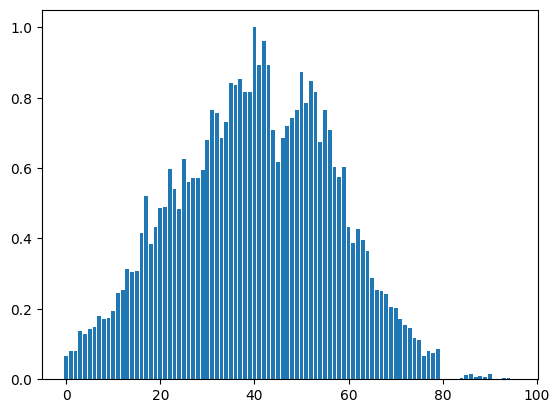

In [33]:
plt.bar(range(len(df[0])), df[0])

<BarContainer object of 96 artists>

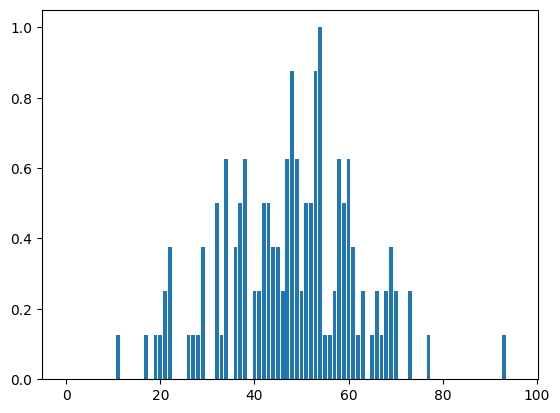

In [37]:
plt.bar(range(len(df[600])), df[244])

In [38]:
residuals = np.abs(df[0] - df[244])

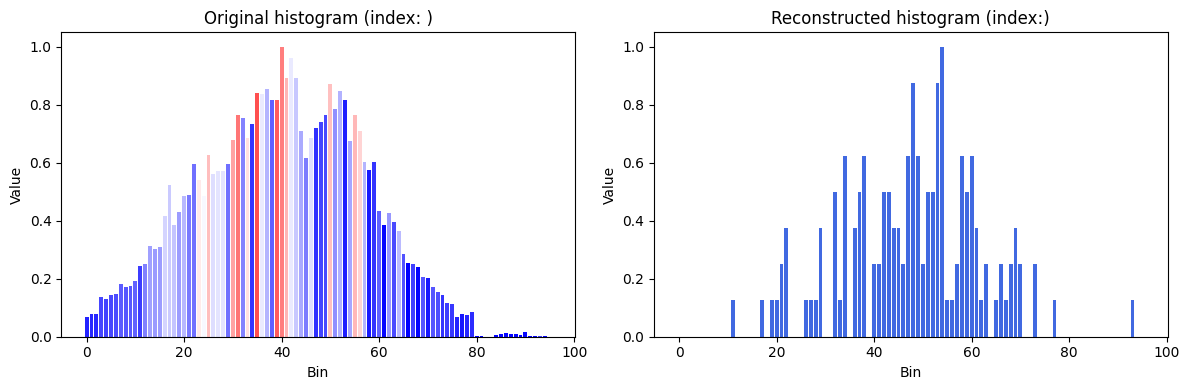

In [66]:
def plot_comparison_w_heatmap(original, recreation, colormap='bwr'):
    
    residuals = np.abs(original - recreation)

    _, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    cmap = plt.get_cmap(colormap)
    colors = cmap(residuals)

    axes[0].bar(range(len(original)), original, zorder=1, color=colors)
    axes[0].set_title(f"Original histogram (index: )")
    axes[0].set_xlabel("Bin")
    axes[0].set_ylabel("Value")

    axes[1].bar(range(len(recreation)), recreation, zorder=1, color='royalblue')
    axes[1].set_title(f"Reconstructed histogram (index:)")
    axes[1].set_xlabel("Bin")
    axes[1].set_ylabel("Value")

    plt.tight_layout()
    plt.show()

plot_comparison_w_heatmap(df[0], df[244])